# Comparativo de Classificadores com Validação Cruzada e Balanceamento

*Investigando se o desbalanceamento de classes explica o recall limitado na predição de renda acima de 50 mil dólares*

**Autor:** Wellington Moreira  
**Contato:** [LinkedIn](https://www.linkedin.com/in/wellington-moreira-santos/) | wsantos08@hotmail.com  
**Data:** Agosto de 2026 | **Versão:** 1.0  
**Dataset:** [Adult Census Income (UCI Machine Learning Repository)](https://uci.edu)  
**Licença:** [MIT](https://opensource.org) (Livre para uso acadêmico e comercial)

---
### Resumo Executivo
Este notebook apresenta um benchmark de algoritmos de classificação (ex: Regressão Logística, Random Forest, XGBoost) aplicados à predição de renda anual. O foco principal é avaliar o impacto de técnicas de balanceamento (como SMOTE ou undersampling) na métrica de **Recall** para a classe minoritária (>50k), utilizando validação cruzada estratificada para garantir a robustez dos resultados.


## 1. Imports e Configurações

In [42]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import session_info

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, confusion_matrix, PrecisionRecallDisplay
from sklearn.base import clone

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

from scipy.stats import wilcoxon

In [3]:
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#f1f5f9',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

pd.set_option('display.max_columns', None)

session_info.show(dependencies=False)

## 2. Coleta e Inspeção dos Dados

### 2.1 Visão Geral

In [4]:
# atributos
columns = [
    "Age",
    "Workclass",
    "Fnlwgt",
    "Education",
    "Education-Num",
    "Marital-Status",
    "Occupation",
    "Relationship",
    "Race",
    "Sex",
    "Capital-Gain",
    "Capital-Loss",
    "Hours-per-Week",
    "Native-Country",
    "Income",
]

# carga 
df = pd.read_csv('data/adult.data', names=columns)
df.head()

,Age,Workclass,Fnlwgt,Education,Education-Num,Marital-Status,Occupation,Relationship,Race,Sex,Capital-Gain,Capital-Loss,Hours-per-Week,Native-Country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# dimensao
df.shape

(32561, 15)

In [6]:
# tipos
df.dtypes

Age               int64
Workclass           str
Fnlwgt            int64
Education           str
Education-Num     int64
Marital-Status      str
Occupation          str
Relationship        str
Race                str
Sex                 str
Capital-Gain      int64
Capital-Loss      int64
Hours-per-Week    int64
Native-Country      str
Income              str
dtype: object

In [7]:
# nulos
df.isnull().sum()

Age               0
Workclass         0
Fnlwgt            0
Education         0
Education-Num     0
Marital-Status    0
Occupation        0
Relationship      0
Race              0
Sex               0
Capital-Gain      0
Capital-Loss      0
Hours-per-Week    0
Native-Country    0
Income            0
dtype: int64

datasets antigos costumam representar ausência de informação com um caractere no lugar de um valor nulo real.

In [8]:
# busca por dominio como nulo 
for col in df.select_dtypes(include='object').columns:
    print( col,(df[col].str.strip() == '?').sum() )

Workclass 1836
Education 0
Marital-Status 0
Occupation 1843
Relationship 0
Race 0
Sex 0
Native-Country 583
Income 0


O dataset tem 32561 registros e 15 colunas, sendo 6 numéricas e 9 categóricas, muitos registros contém atributos com dados ausentes mascarados com '?'.

### 2.2 Estatísticas Descritivas

In [9]:
df.describe()

,Age,Fnlwgt,Education-Num,Capital-Gain,Capital-Loss,Hours-per-Week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


A idade média é de aproximadamente 38,6 anos, com mínimo de 17 e máximo de 90. 

`capital-gain` e `capital-loos` têm médias muito baixas frente aos seus valores máximos (99999 e 4356, respectivamente), o que indica distribuições extremamente assimétricas, com a maioria dos registros em zero e poucos valores muito altos. 

`hour-per-week` tem média de 40,4 horas, consistente com jornada de trabalho padrão.

### 2.3 Distribuição da Variável Alvo

In [10]:
df['Income'].value_counts()

Income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [11]:
df['Income'].value_counts(normalize=True)

Income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64

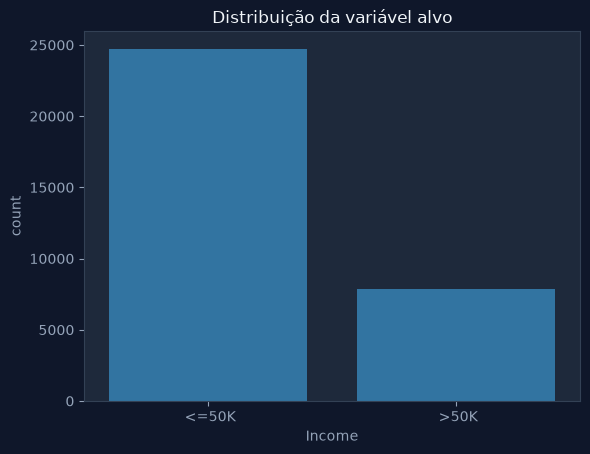

In [12]:
sns.countplot(x='Income', data=df)
plt.title('Distribuição da variável alvo')
plt.show()

A classe `<=50K` tem 24720 registros e a classe `>50K` tem 7841, uma proporção de aproximadamente 76% contra 24%. Esse desbalanceamento é o ponto de partida da pergunta central deste projeto.

## 3. Análise Exploratória

### 3.1 Existe redundância entre `Education` e `Education-num`?

In [7]:
df['Education'].unique()

<StringArray>
[   ' Bachelors',      ' HS-grad',         ' 11th',      ' Masters',
          ' 9th', ' Some-college',   ' Assoc-acdm',    ' Assoc-voc',
      ' 7th-8th',    ' Doctorate',  ' Prof-school',      ' 5th-6th',
         ' 10th',      ' 1st-4th',    ' Preschool',         ' 12th']
Length: 16, dtype: str

In [8]:
df['Education-Num'].unique()

array([13,  9,  7, 14,  5, 10, 12, 11,  4, 16, 15,  3,  6,  2,  1,  8])

In [5]:
df.groupby('Education')['Education-Num'].nunique()

Education
10th            1
11th            1
12th            1
1st-4th         1
5th-6th         1
7th-8th         1
9th             1
Assoc-acdm      1
Assoc-voc       1
Bachelors       1
Doctorate       1
HS-grad         1
Masters         1
Preschool       1
Prof-school     1
Some-college    1
Name: Education-Num, dtype: int64

Confirmado, carregam a mesma informação em formatos diferentes, categórico e ordinal, o que tornaria uma delas redundante para o modelo.

### 3.2 O peso amostral (`fnlwgt`) tem alguma correlação com o alvo?

In [10]:
# unicos do income 
df.Income.unique()

<StringArray>
[' <=50K', ' >50K']
Length: 2, dtype: str

In [12]:
# mapeamento binario
df['Income'].map({' <=50K': 0, ' >50K': 1})

0        0
1        0
2        0
3        0
4        0
        ..
32556    0
32557    1
32558    0
32559    0
32560    1
Name: Income, Length: 32561, dtype: int64

In [13]:
# correlacao
df['Fnlwgt'].corr(
    df['Income'].map({' <=50K': 0, ' >50K': 1})
)

np.float64(-0.009462557247529244)

A coluna `final-weight` (`fnlwgt`) é um peso amostral atribuído pelo Census Bureau dos Estados Unidos para tornar a amostra representativa da população, não uma característica do indivíduo entrevistado, e como visto possui baixa correlação.

### 3.3 Correlação entre Variáveis Numéricas e o Alvo

In [15]:
# atributos numericos
df.select_dtypes(include='number').columns

Index(['Age', 'Fnlwgt', 'Education-Num', 'Capital-Gain', 'Capital-Loss',
       'Hours-per-Week'],
      dtype='str')

In [20]:
# correlaçao com alvo binario
df[['Age', 'Education-Num', 'Capital-Gain', 'Capital-Loss',
       'Hours-per-Week']].assign(Income=df['Income'].map({' <=50K': 0, ' >50K': 1})).corr()

,Age,Education-Num,Capital-Gain,Capital-Loss,Hours-per-Week,Income
Age,1.000000,0.036527,0.077674,0.057775,0.068756,0.234037
Education-Num,0.036527,1.000000,0.122630,0.079923,0.148123,0.335154
Capital-Gain,0.077674,0.122630,1.000000,-0.031615,0.078409,0.223329
Capital-Loss,0.057775,0.079923,-0.031615,1.000000,0.054256,0.150526
Hours-per-Week,0.068756,0.148123,0.078409,0.054256,1.000000,0.229689
Income,0.234037,0.335154,0.223329,0.150526,0.229689,1.000000


In [22]:
df.select_dtypes(include='number').assign().corr()

,Age,Fnlwgt,Education-Num,Capital-Gain,Capital-Loss,Hours-per-Week
Age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
Fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
Education-Num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
Capital-Gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
Capital-Loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
Hours-per-Week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


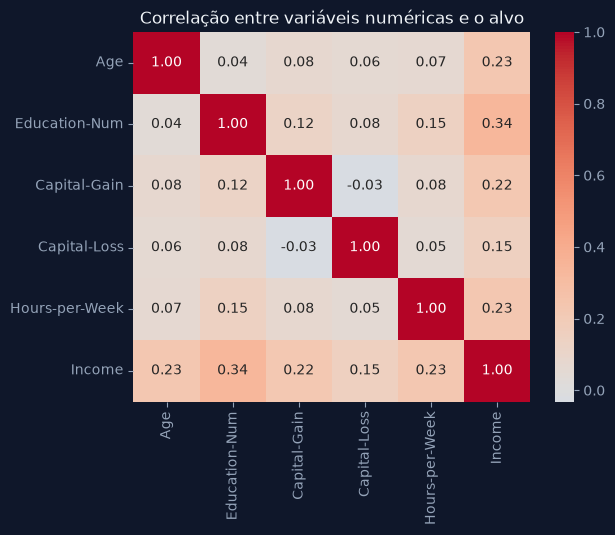

In [23]:
# visualizaão
sns.heatmap( (
    df[['Age', 'Education-Num', 'Capital-Gain', 'Capital-Loss','Hours-per-Week']]
        .assign(Income=df['Income']
        .map({' <=50K': 0, ' >50K': 1}))
        .corr() 
    ),
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0)
plt.title('Correlação entre variáveis numéricas e o alvo')
plt.show()

### 3.4 Distribuição de Idade e Horas Trabalhadas por Classe de Renda

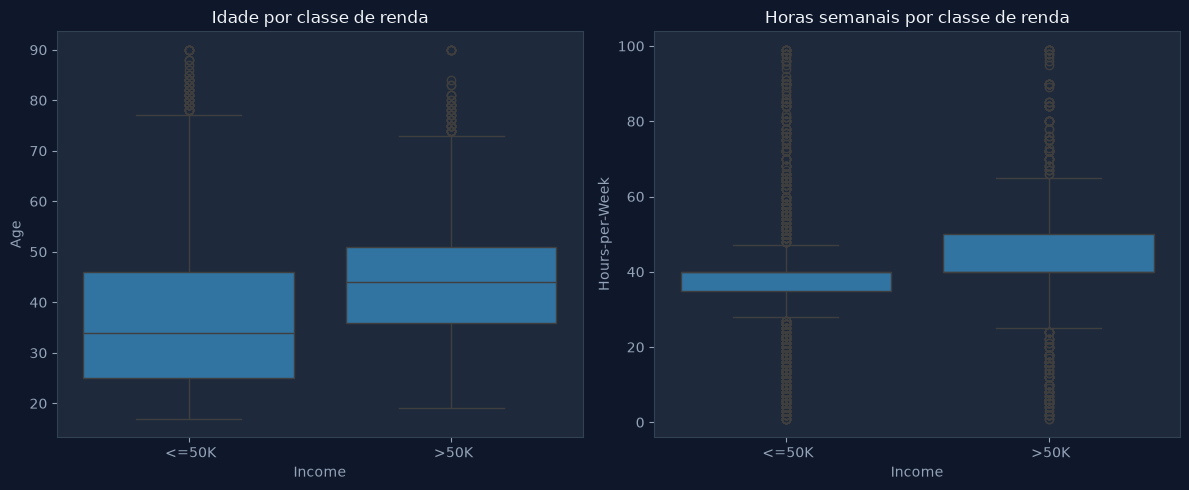

In [25]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Income', y='Age', data=df, ax=eixos[0])
eixos[0].set_title('Idade por classe de renda')

sns.boxplot(x='Income', y='Hours-per-Week', data=df, ax=eixos[1])
eixos[1].set_title('Horas semanais por classe de renda')

plt.tight_layout()
plt.show()

### Resumo das Decisões da Análise Exploratória

| Coluna | Decisão | Justificativa |
|---|---|---|
| `Education` | Remover | Redundante com `Education-Num` |
| `Fnlwgt` | Remover | Peso amostral, não é atributo do indivíduo |
| `Workclass`, `Occupation` | Tratar `?` como categoria própria | Preserva informação, volume relevante de ausentes |
| `Native-Country` | Remover linhas com `?` | Proporção baixa de ausentes esperada |

## 4. Tratamento e Limpeza dos Dados

### 4.1 Remoção de Colunas Não Informativas

In [13]:
df = df.drop(columns=['Education', 'Fnlwgt'])
df.head()

,Age,Workclass,Education-Num,Marital-Status,Occupation,Relationship,Race,Sex,Capital-Gain,Capital-Loss,Hours-per-Week,Native-Country,Income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### 4.2 Tratamento de Valores Ausentes Disfarçados

In [14]:
# laço para replace
for col in ['Workclass', 'Occupation']:
    df[col] = df[col].astype(str).str.strip().replace('?', 'Nao_informado')

In [15]:
# check
df['Workclass'].unique(), df['Occupation'].unique()

(<StringArray>
 [       'State-gov', 'Self-emp-not-inc',          'Private',
       'Federal-gov',        'Local-gov',    'Nao_informado',
      'Self-emp-inc',      'Without-pay',     'Never-worked']
 Length: 9, dtype: str,
 <StringArray>
 [     'Adm-clerical',   'Exec-managerial', 'Handlers-cleaners',
     'Prof-specialty',     'Other-service',             'Sales',
       'Craft-repair',  'Transport-moving',   'Farming-fishing',
  'Machine-op-inspct',      'Tech-support',     'Nao_informado',
    'Protective-serv',      'Armed-Forces',   'Priv-house-serv']
 Length: 15, dtype: str)

In [16]:
df = df[df['Native-Country'].astype(str).str.strip() != '?']

In [17]:
df['Native-Country'].unique()

<StringArray>
[             ' United-States',                       ' Cuba',
                    ' Jamaica',                      ' India',
                     ' Mexico',                      ' South',
                ' Puerto-Rico',                   ' Honduras',
                    ' England',                     ' Canada',
                    ' Germany',                       ' Iran',
                ' Philippines',                      ' Italy',
                     ' Poland',                   ' Columbia',
                   ' Cambodia',                   ' Thailand',
                    ' Ecuador',                       ' Laos',
                     ' Taiwan',                      ' Haiti',
                   ' Portugal',         ' Dominican-Republic',
                ' El-Salvador',                     ' France',
                  ' Guatemala',                      ' China',
                      ' Japan',                 ' Yugoslavia',
                       ' Peru', ' Outlyin

In [18]:
# metricas
sum(df['Workclass'] == 'Nao_informado') + sum(df['Occupation'] == 'Nao_informado'), df.shape[0]

(3625, 31978)

### 4.4 Resumo Consolidado do Tratamento

| Etapa | Impacto |
|---|---|
| Colunas removidas | `Education`, `Fnlwgt` |
| `Workclass`/`Occupation` tratados | 3625  |
| Linhas removidas (`Native-Country`) |583 |
| Total de registros após tratamento | 31978 |

## 5. Preparação para o Modelo

### 5.1 Separação de Features e Alvo

In [20]:
X = df.drop(columns='Income')
y = df['Income'].map({' <=50K': 0, ' >50K': 1})

X.shape, y.shape

((31978, 12), (31978,))

Alvo para um formato binário explícito, com 1 representando a classe de interesse (`>50K`), o que deixa as métricas de recall e precisão mais diretas de interpretar.

### 5.2 Pré-processador



In [21]:
# separação de atributos para preprocessador
colunas_categoricas = X.select_dtypes(include='object').columns.tolist()
colunas_numericas   = X.select_dtypes(exclude='object').columns.tolist()

colunas_categoricas, colunas_numericas

(['Workclass',
  'Marital-Status',
  'Occupation',
  'Relationship',
  'Race',
  'Sex',
  'Native-Country'],
 ['Age', 'Education-Num', 'Capital-Gain', 'Capital-Loss', 'Hours-per-Week'])

In [27]:
# pipeline
preprocessador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), colunas_categoricas) # handle evita erro em categoria q nao estavam no treino
    ]
)

`OneHotEncoder` apenas nas colunas categóricas e `StandardScaler` apenas nas colunas numéricas contínuas.

### 5.3 Validação Cruzada Estratificada

In [23]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

Validação cruzada estratificada com 10 folds para garantir que a proporção de classes se mantenha em cada divisão.

## 6. Treinamento do Modelo

### 6.1 Modelos Base, Sem Balanceamento

In [29]:
# modelos
modelos = {
    'Naive Bayes'         : GaussianNB(),
    'Arvore de Decisão'   : DecisionTreeClassifier(criterion='entropy', random_state=42),
    'Random Forest'       : RandomForestClassifier(criterion='entropy', random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=10),
    'Regressão Logística' : LogisticRegression(random_state=42, max_iter=1000),
    'SVM'                 : SVC(kernel='linear', random_state=42),
    'MLP'                 : MLPClassifier(max_iter=1000, tol=1e-5, hidden_layer_sizes=(55,55), random_state=42)
}


In [25]:
# metricas
metricas_scoring = {
    'recall'  : 'recall',
    'precisao': 'precision',
    'f1'      : 'f1',
    'acuracia': 'accuracy'
}

### 6.2 Resultados Sem Balanceamento

In [30]:
# modelos
resultados_sem_balanceamento = {}

for nome, modelo in modelos.items():
    pipeline = Pipeline([
        ('preprocessador', preprocessador),
        ('classificador' , modelo)
    ])
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=metricas_scoring)
    resultados_sem_balanceamento[nome] = scores

In [31]:
# resultados
resumo_sem_balanceamento = pd.DataFrame({
    
    nome: {
        'recall_medio'    : scores['test_recall'].mean(),
        'recall_dp'       : scores['test_recall'].std(),
        'precisao_media'  : scores['test_precisao'].mean(),
        'f1_medio'        : scores['test_f1'].mean(),
        'acuracia_media'  : scores['test_acuracia'].mean()
    }
    for nome, scores in resultados_sem_balanceamento.items()
}).T.sort_values('recall_medio', ascending=False)

resumo_sem_balanceamento

,recall_medio,recall_dp,precisao_media,f1_medio,acuracia_media
Naive Bayes,0.956466,0.005453,0.340680,0.502377,0.543906
Random Forest,0.622608,0.020510,0.710552,0.663645,0.848177
Arvore de Decisão,0.616369,0.022914,0.634936,0.625417,0.822346
MLP,0.605203,0.022010,0.679719,0.639993,0.836199
Regressão Logística,0.603895,0.021713,0.733345,0.662305,0.851898
SVM,0.598438,0.021246,0.734989,0.659661,0.851491
KNN,0.564781,0.022563,0.728236,0.636056,0.844549


### 6.3 Investigação do Desempenho Anômalo do Naive Bayes

In [32]:
X_transformado = preprocessador.fit_transform(X)
X_transformado = np.asarray(X_transformado.todense()) if hasattr(X_transformado, 'todense') else X_transformado
X_transformado

array([[ 0.030814  ,  1.14376803,  0.15203701, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.83597458,  1.14376803, -0.14583315, ...,  1.        ,
         0.        ,  0.        ],
       [-0.04238241, -0.41834925, -0.14583315, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 1.42154591, -0.41834925, -0.14583315, ...,  1.        ,
         0.        ,  0.        ],
       [-1.21352508, -0.41834925, -0.14583315, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.98236741, -0.41834925,  1.91267706, ...,  1.        ,
         0.        ,  0.        ]], shape=(31978, 90))

In [33]:
n_colunas_binarias = sum(len(np.unique(X_transformado[:, i])) == 2 for i in range(X_transformado.shape[1]))
print(f"Colunas binárias: {n_colunas_binarias} de {X_transformado.shape[1]}")

Colunas binárias: 85 de 90


O Naive Bayes Gaussiano assume que cada atributo segue uma distribuição normal dentro de cada classe. Depois do one hot encoding, a maior parte das colunas se torna binária, o que viola diretamente essa suposição. Isso explica por que o desempenho tão inferior aos demais modelos.

### 6.4 Pipeline com Balanceamento Dentro da Validação Cruzada

In [34]:
# modelos
resultados_com_balanceamento = {}

for nome, modelo in modelos.items():
    pipeline = ImbPipeline([
        ('preprocessador', preprocessador),
        ('balanceamento', SMOTETomek(random_state=42)),
        ('classificador', modelo)
    ])
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=metricas_scoring)
    resultados_com_balanceamento[nome] = scores

`SMOTETomek` dentro do próprio pipeline de validação cruzada garante que a reamostragem aconteça apenas nos dados de treino de cada fold, sem vazamento de informação do fold de teste.

### 6.5 Resultados Com Balanceamento

In [35]:
resumo_com_balanceamento = pd.DataFrame({
    nome: {
        'recall_medio': scores['test_recall'].mean(),
        'recall_dp': scores['test_recall'].std(),
        'precisao_media': scores['test_precisao'].mean(),
        'f1_medio': scores['test_f1'].mean(),
        'acuracia_media': scores['test_acuracia'].mean()
    }
    for nome, scores in resultados_com_balanceamento.items()
}).T.sort_values('recall_medio', ascending=False)

resumo_com_balanceamento

,recall_medio,recall_dp,precisao_media,f1_medio,acuracia_media
Naive Bayes,0.943472,0.004258,0.336746,0.496319,0.539121
SVM,0.861856,0.017590,0.551586,0.672627,0.798142
Regressão Logística,0.847949,0.019739,0.572575,0.683503,0.811057
KNN,0.795970,0.018656,0.575846,0.668191,0.809806
MLP,0.745155,0.033116,0.588935,0.657253,0.813090
Random Forest,0.689404,0.019304,0.660230,0.674417,0.839890
Arvore de Decisão,0.638071,0.020351,0.614172,0.625808,0.816436


### 6.6 Teste de Wilcoxon: o Ganho de Recall é Significativo?

In [36]:
resultados_wilcoxon = {}

for nome in modelos.keys():
    recall_sem = resultados_sem_balanceamento[nome]['test_recall']
    recall_com = resultados_com_balanceamento[nome]['test_recall']
    estatistica, p_valor = wilcoxon(recall_com, recall_sem)
    resultados_wilcoxon[nome] = {'estatistica': estatistica, 'p_valor': p_valor}

pd.DataFrame(resultados_wilcoxon).T

,estatistica,p_valor
Naive Bayes,0.0,0.001953
Arvore de Decisão,3.0,0.009766
Random Forest,0.0,0.001953
KNN,0.0,0.001953
Regressão Logística,0.0,0.001953
SVM,0.0,0.001953
MLP,0.0,0.001953


Para cada modelo, comparei o recall obtido em cada um dos 10 folds sem balanceamento contra o recall no mesmo fold com balanceamento. Como são as mesmas divisões de dados nas duas condições, usei o teste de Wilcoxon para amostras pareadas, adequado para verificar se a diferença é sistemática ou apenas variação aleatória entre folds.

## 7. Avaliação do Modelo

### 7.1 Comparação Final Sem Vs. Com Balanceamento

In [37]:
comparacao_final = pd.DataFrame({
    'recall_sem_balanceamento': resumo_sem_balanceamento['recall_medio'],
    'recall_com_balanceamento': resumo_com_balanceamento['recall_medio']
})
comparacao_final['ganho'] = comparacao_final['recall_com_balanceamento'] - comparacao_final['recall_sem_balanceamento']
comparacao_final.sort_values('ganho', ascending=False)

,recall_sem_balanceamento,recall_com_balanceamento,ganho
SVM,0.598438,0.861856,0.263418
Regressão Logística,0.603895,0.847949,0.244054
KNN,0.564781,0.795970,0.231189
MLP,0.605203,0.745155,0.139953
Random Forest,0.622608,0.689404,0.066796
Arvore de Decisão,0.616369,0.638071,0.021702
Naive Bayes,0.956466,0.943472,-0.012995


### 7.2 Curvas de Precisão-Recall do Melhor Modelo

In [46]:
melhor_modelo_nome = resumo_com_balanceamento['f1_medio'].idxmax()
melhor_modelo = modelos[melhor_modelo_nome]

melhor_modelo_nome, melhor_modelo

('Regressão Logística', LogisticRegression(max_iter=1000, random_state=42))

In [47]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

pipeline_sem = Pipeline([('preprocessador', preprocessador), ('classificador', clone(melhor_modelo))])
pipeline_com = ImbPipeline([('preprocessador', preprocessador), ('balanceamento', SMOTETomek(random_state=42)), ('classificador', clone(melhor_modelo))])

pipeline_sem.fit(X_treino, y_treino)
pipeline_com.fit(X_treino, y_treino)

,steps,"[('preprocessador', ...), ('balanceamento', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](12,)","['Age','Workclass','Education-Num',...,'Capital-Loss','Hours-per-Week', 'Native-Country']"
n_features_in_,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


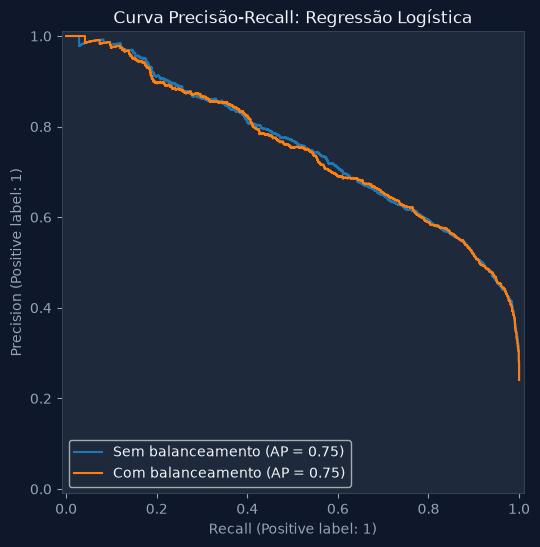

In [48]:
fig, eixo = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_estimator(pipeline_sem, X_teste, y_teste, name='Sem balanceamento', ax=eixo)
PrecisionRecallDisplay.from_estimator(pipeline_com, X_teste, y_teste, name='Com balanceamento', ax=eixo)
plt.title(f'Curva Precisão-Recall: {melhor_modelo_nome}')
plt.show()

Para essa visualização, uso uma única divisão treino/teste estratificada, separada da validação cruzada, apenas para gerar as curvas de diagnóstico do modelo com melhor recall médio.

### 7.3 Matrizes de Confusão Comparativas

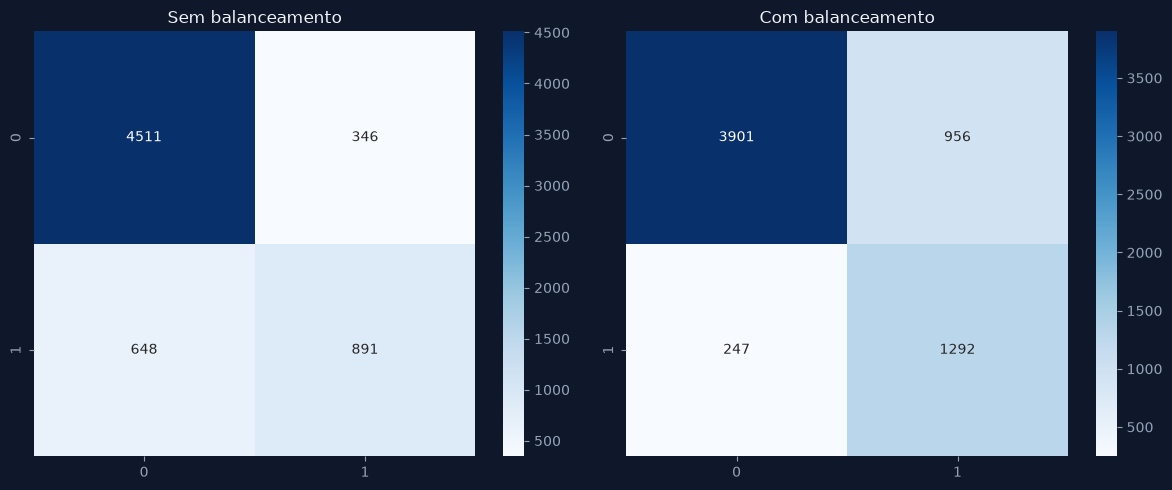

In [49]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

y_pred_sem = pipeline_sem.predict(X_teste)
y_pred_com = pipeline_com.predict(X_teste)

sns.heatmap(confusion_matrix(y_teste, y_pred_sem), annot=True, fmt='d', cmap='Blues', ax=eixos[0])
eixos[0].set_title('Sem balanceamento')

sns.heatmap(confusion_matrix(y_teste, y_pred_com), annot=True, fmt='d', cmap='Blues', ax=eixos[1])
eixos[1].set_title('Com balanceamento')

plt.tight_layout()
plt.show()